# Cournot Competition Game

This notebook demonstrates the Cournot competition game with two firms.

## Model
- Two firms choose quantities $q_1$ and $q_2$
- Price: $P = a - b \cdot Q$ where $Q = q_1 + q_2$
- Cost: $C_i = c \cdot q_i$
- Profit: $\pi_i = P \cdot q_i - C_i = (a - b \cdot Q) \cdot q_i - c \cdot q_i$

## Nash Equilibrium
For symmetric firms with linear demand and constant marginal cost:
- Equilibrium quantity: $q^* = \frac{a - c}{3b}$
- Equilibrium price: $P^* = a - 2b \cdot q^*$
- Equilibrium profit: $\pi^* = b \cdot (q^*)^2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from games.cournot import Cournot
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
from agents.random_agent import RandomAgent

## Funciones utilitarias

Funciones compartidas usadas en todos los experimentos del notebook.

In [2]:
def best_response(q_j, a, b, c):
    return np.maximum(0, (a - c - b * q_j) / (2 * b))


def run_experiment(game, agents_dict, iterations, sample_rate=10):
    history = {'q1': [], 'q2': [], 'profit1': [], 'profit2': []}
    for i in range(iterations):
        actions = {ag: agents_dict[ag].action() for ag in game.agents}
        _, rewards, _, _, _ = game.step(actions)
        if i % sample_rate == 0:
            history['q1'].append(game._quantities[actions[game.agents[0]]])
            history['q2'].append(game._quantities[actions[game.agents[1]]])
            history['profit1'].append(rewards[game.agents[0]])
            history['profit2'].append(rewards[game.agents[1]])
    return history


def run_experiment_n(game, agents_dict, iterations, sample_rate=10):
    history = {'q': {ag: [] for ag in game.agents}, 'profit': {ag: [] for ag in game.agents}}
    for i in range(iterations):
        actions = {ag: agents_dict[ag].action() for ag in game.agents}
        _, rewards, _, _, _ = game.step(actions)
        if i % sample_rate == 0:
            for ag in game.agents:
                history['q'][ag].append(game._quantities[actions[ag]])
                history['profit'][ag].append(rewards[ag])
    return history


def print_strategy(game, agents_dict, algo_name, q_star):
    print(f"Learned strategies ({algo_name}):")
    for agent in game.agents:
        q = game._quantities[np.argmax(agents_dict[agent].policy())]
        print(f"  {agent}: Most probable quantity = {q:.4f} (Nash: {q_star:.4f})")


def plot_convergence(history, iterations, sample_rate, q_star, profit_star, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    x = range(0, iterations, sample_rate)
    ax1.plot(x, history['q1'], 'b-', alpha=0.6, label='Firm 1')
    ax1.plot(x, history['q2'], 'r-', alpha=0.6, label='Firm 2')
    ax1.axhline(y=q_star, color='g', linestyle='--', linewidth=2, label=f'Nash ({q_star:.2f})')
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Quantity', fontsize=12)
    ax1.set_title(f'Quantity Convergence ({title})', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(x, history['profit1'], 'b-', alpha=0.6, label='Firm 1')
    ax2.plot(x, history['profit2'], 'r-', alpha=0.6, label='Firm 2')
    ax2.axhline(y=profit_star, color='g', linestyle='--', linewidth=2, label=f'Nash Profit ({profit_star:.2f})')
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('Profit', fontsize=12)
    ax2.set_title(f'Profit Convergence ({title})', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_convergence_n(game, history, iterations, sample_rate, q_star, profit_star, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    x = range(0, iterations, sample_rate)
    colors = ['b-', 'r-', 'g-', 'c-', 'm-']
    for i, agent in enumerate(game.agents):
        ax1.plot(x, history['q'][agent], colors[i], alpha=0.6, label=f'Firm {i+1}')
        ax2.plot(x, history['profit'][agent], colors[i], alpha=0.6, label=f'Firm {i+1}')
    ax1.axhline(y=q_star, color='purple', linestyle='--', linewidth=2, label=f'Nash ({q_star:.2f})')
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Quantity', fontsize=12)
    ax1.set_title(f'Quantity Convergence – {title}', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.axhline(y=profit_star, color='purple', linestyle='--', linewidth=2, label=f'Nash Profit ({profit_star:.2f})')
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('Profit', fontsize=12)
    ax2.set_title(f'Profit Convergence – {title}', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def get_final_q(game, agents_dict):
    return game._quantities[np.argmax(agents_dict[game.agents[0]].policy())]


def get_avg_profit(game, agents_dict):
    quantities = {ag: game._quantities[np.argmax(agents_dict[ag].policy())] for ag in game.agents}
    q_total = sum(quantities.values())
    return np.mean([game._compute_profit(quantities[ag], q_total) for ag in game.agents])

## Initialize the Game

Default parameters: $a=25$, $b=2$, $c=1$

In [3]:
# Create game with default parameters
g = Cournot(a=25.0, b=2.0, c=1.0, max_quantity=10, num_actions=21)
g.reset()

## Nash Equilibrium

Calculate the theoretical Nash equilibrium:

In [4]:
q_star, P_star, profit_star = g.get_nash_equilibrium()
print(f"Nash Equilibrium:")
print(f"  Quantity per firm: {q_star:.4f}")
print(f"  Total quantity: {2*q_star:.4f}")
print(f"  Price: {P_star:.4f}")
print(f"  Profit per firm: {profit_star:.4f}")

Nash Equilibrium:
  Quantity per firm: 4.0000
  Total quantity: 8.0000
  Price: 9.0000
  Profit per firm: 32.0000


## Visualize Best Response Functions

Plot the best response functions for both firms:

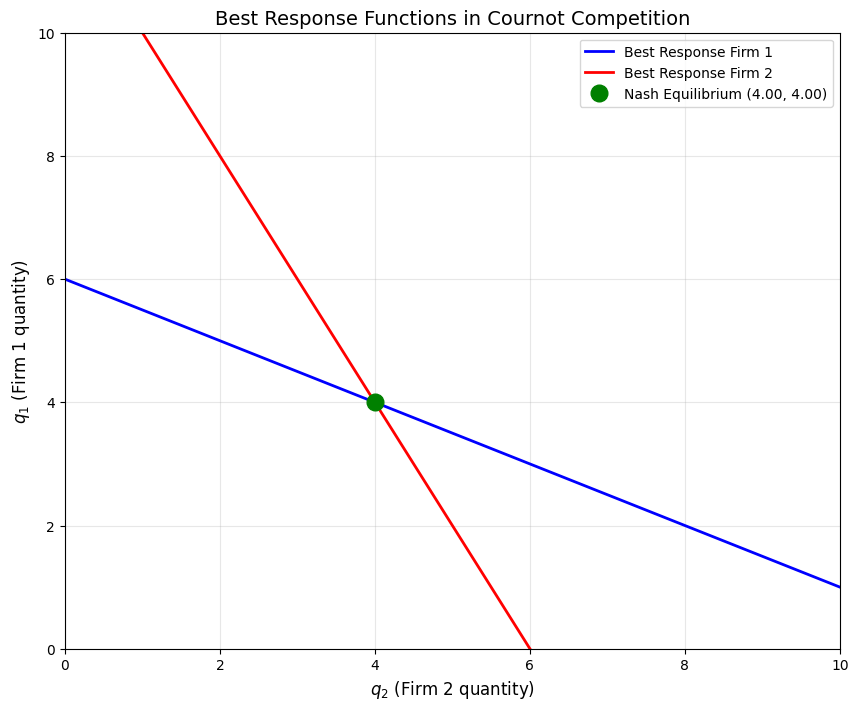

In [5]:
q_range = np.linspace(0, g.max_quantity, 100)

br_1 = best_response(q_range, g.a, g.b, g.c)
br_2 = best_response(q_range, g.a, g.b, g.c)  # symmetric

plt.figure(figsize=(10, 8))
plt.plot(q_range, br_1, 'b-', linewidth=2, label='Best Response Firm 1')
plt.plot(br_2, q_range, 'r-', linewidth=2, label='Best Response Firm 2')
plt.plot(q_star, q_star, 'go', markersize=12, label=f'Nash Equilibrium ({q_star:.2f}, {q_star:.2f})')
plt.xlabel('$q_2$ (Firm 2 quantity)', fontsize=12)
plt.ylabel('$q_1$ (Firm 1 quantity)', fontsize=12)
plt.title('Best Response Functions in Cournot Competition', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, g.max_quantity])
plt.ylim([0, g.max_quantity])
plt.show()

## Learning with Regret Matching

In [6]:
g.reset()
rm = dict(map(lambda agent: (agent, RegretMatching(game=g, agent=agent, seed=42)), g.agents))

In [7]:
history = run_experiment(g, rm, iterations=500)
print_strategy(g, rm, 'Regret Matching', q_star)

Learned strategies (Regret Matching):
  agent_0: Most probable quantity = 4.0000 (Nash: 4.0000)
  agent_1: Most probable quantity = 4.0000 (Nash: 4.0000)


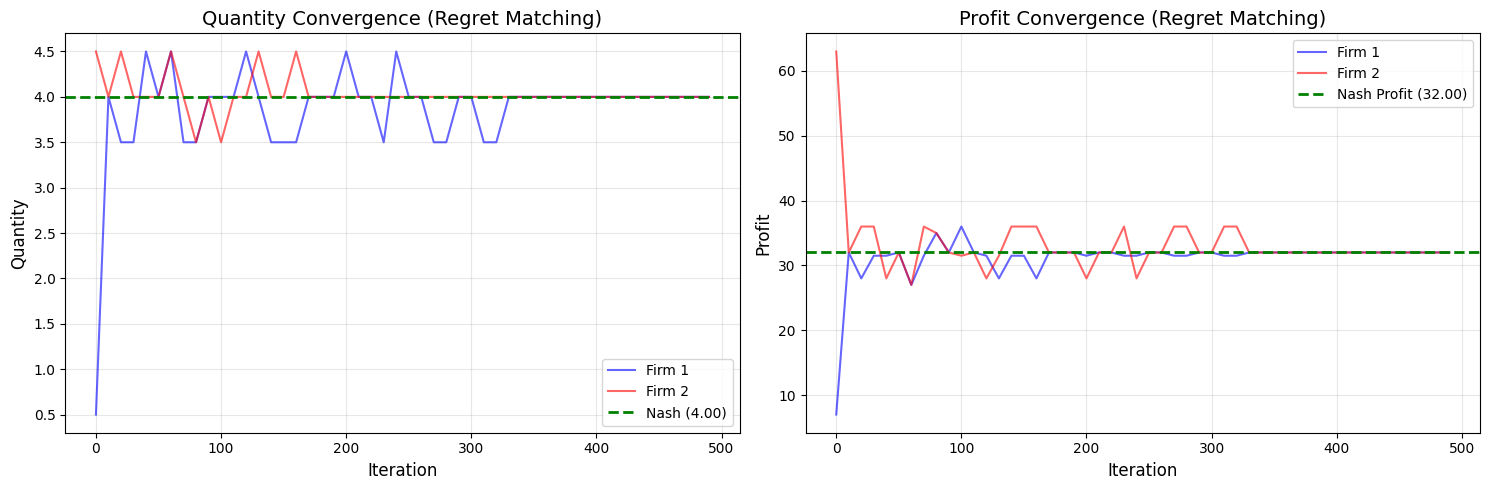

In [8]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Regret Matching')

## Learning with Fictitious Play

In [9]:
g.reset()
fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=42)), g.agents))

In [10]:
history = run_experiment(g, fp, iterations=500)
print_strategy(g, fp, 'Fictitious Play', q_star)

Learned strategies (Fictitious Play):
  agent_0: Most probable quantity = 4.0000 (Nash: 4.0000)
  agent_1: Most probable quantity = 4.0000 (Nash: 4.0000)


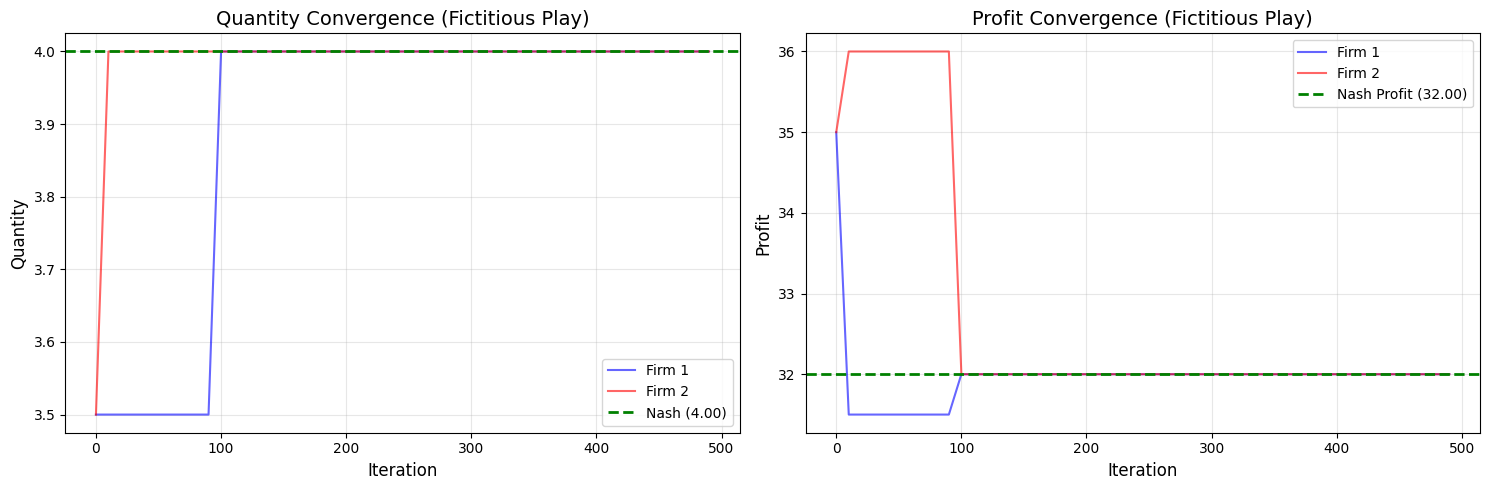

In [11]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Fictitious Play')

## Learning with Independent Q-Learning (IQL)

IQL treats each agent independently: each firm learns a Q-table over its own actions without explicitly modeling the opponent, using ε-greedy exploration with decaying ε.

In [12]:
g.reset()
iql = dict(map(lambda agent: (agent, IndependentQLearning(game=g, agent=agent, seed=42)), g.agents))

history = run_experiment(g, iql, iterations=500)
print_strategy(g, iql, 'Independent Q-Learning', q_star)

Learned strategies (Independent Q-Learning):
  agent_0: Most probable quantity = 3.5000 (Nash: 4.0000)
  agent_1: Most probable quantity = 3.5000 (Nash: 4.0000)


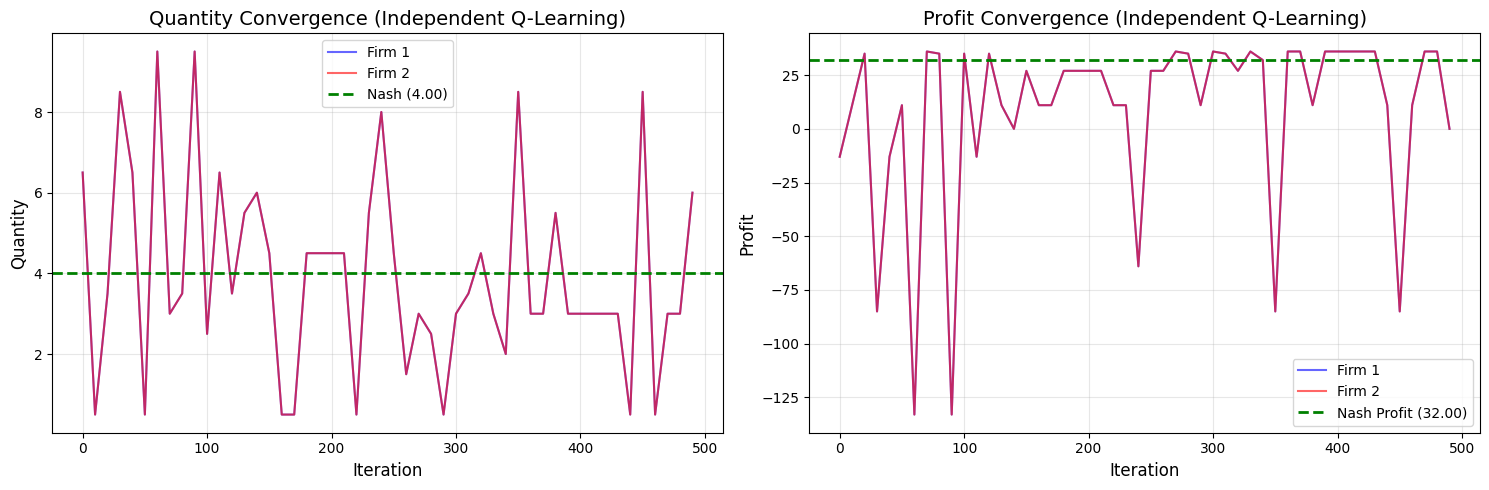

In [13]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Independent Q-Learning')

## Learning with Joint-Action Learning with Agent Modeling (JAL-AM)

JAL-AM explicitly models the opponent's policy by counting their observed actions, then computes the Action-Value (AV) function as the expected Q-value under the opponent model. In Cournot, each firm can observe the opponent's chosen quantity after each step.

In [14]:
g.reset()
jalam = dict(map(lambda agent: (agent, JointActionLearningAM(game=g, agent=agent, seed=42)), g.agents))

history = run_experiment(g, jalam, iterations=500)
print_strategy(g, jalam, 'JAL-AM', q_star)

Learned strategies (JAL-AM):
  agent_0: Most probable quantity = 3.5000 (Nash: 4.0000)
  agent_1: Most probable quantity = 3.5000 (Nash: 4.0000)


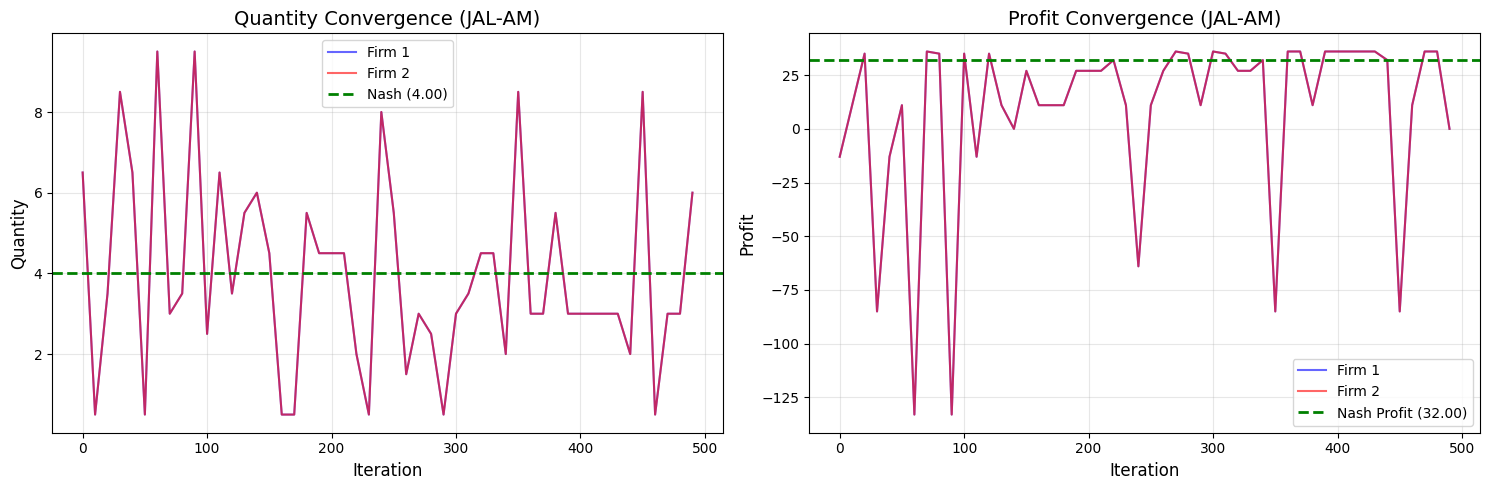

In [15]:
plot_convergence(history, 500, 10, q_star, profit_star, 'JAL-AM')

## Random Agent (Baseline)

The Random Agent selects quantities uniformly at random. It does not learn and serves as a performance baseline.

In [16]:
g.reset()
rand = dict(map(lambda agent: (agent, RandomAgent(game=g, agent=agent, seed=42)), g.agents))

history = run_experiment(g, rand, iterations=500)
avg_q = np.mean(history['q1'] + history['q2'])
avg_profit = np.mean(history['profit1'] + history['profit2'])
print(f"Random Agent (baseline):")
print(f"  Average quantity: {avg_q:.4f} (Nash: {q_star:.4f})")
print(f"  Average profit:   {avg_profit:.4f} (Nash: {profit_star:.4f})")

Random Agent (baseline):
  Average quantity: 4.9450 (Nash: 4.0000)
  Average profit:   5.0350 (Nash: 32.0000)


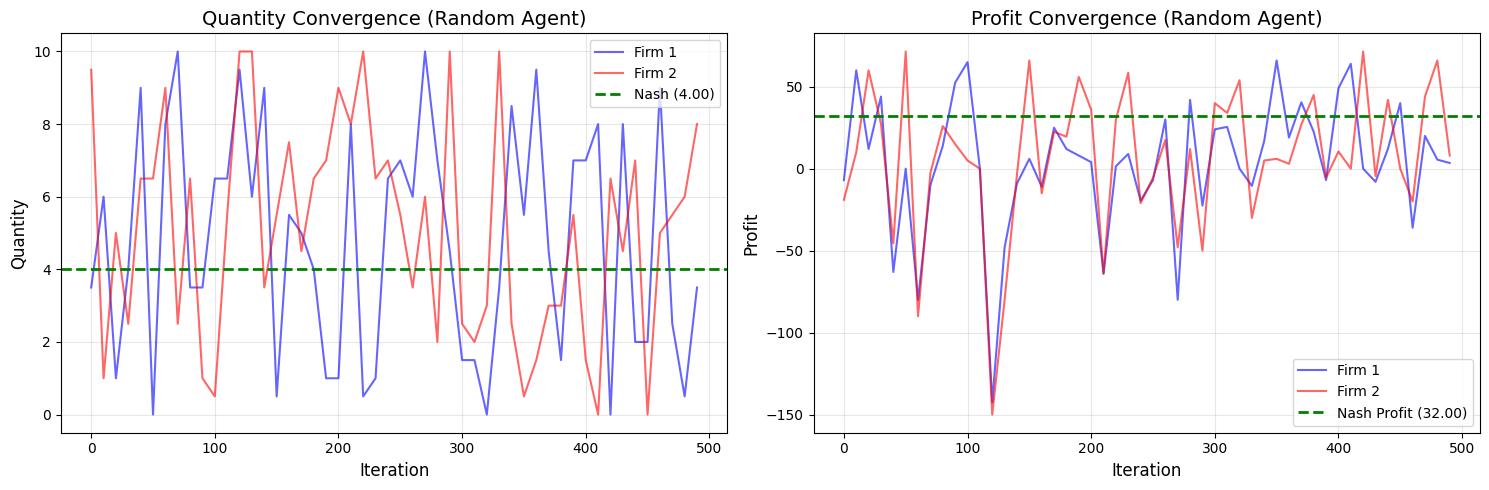

In [17]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Random Agent')

## Strategy Distribution Comparison (All Algorithms)

Comparing the learned strategy distributions across all five algorithms versus the Nash equilibrium:

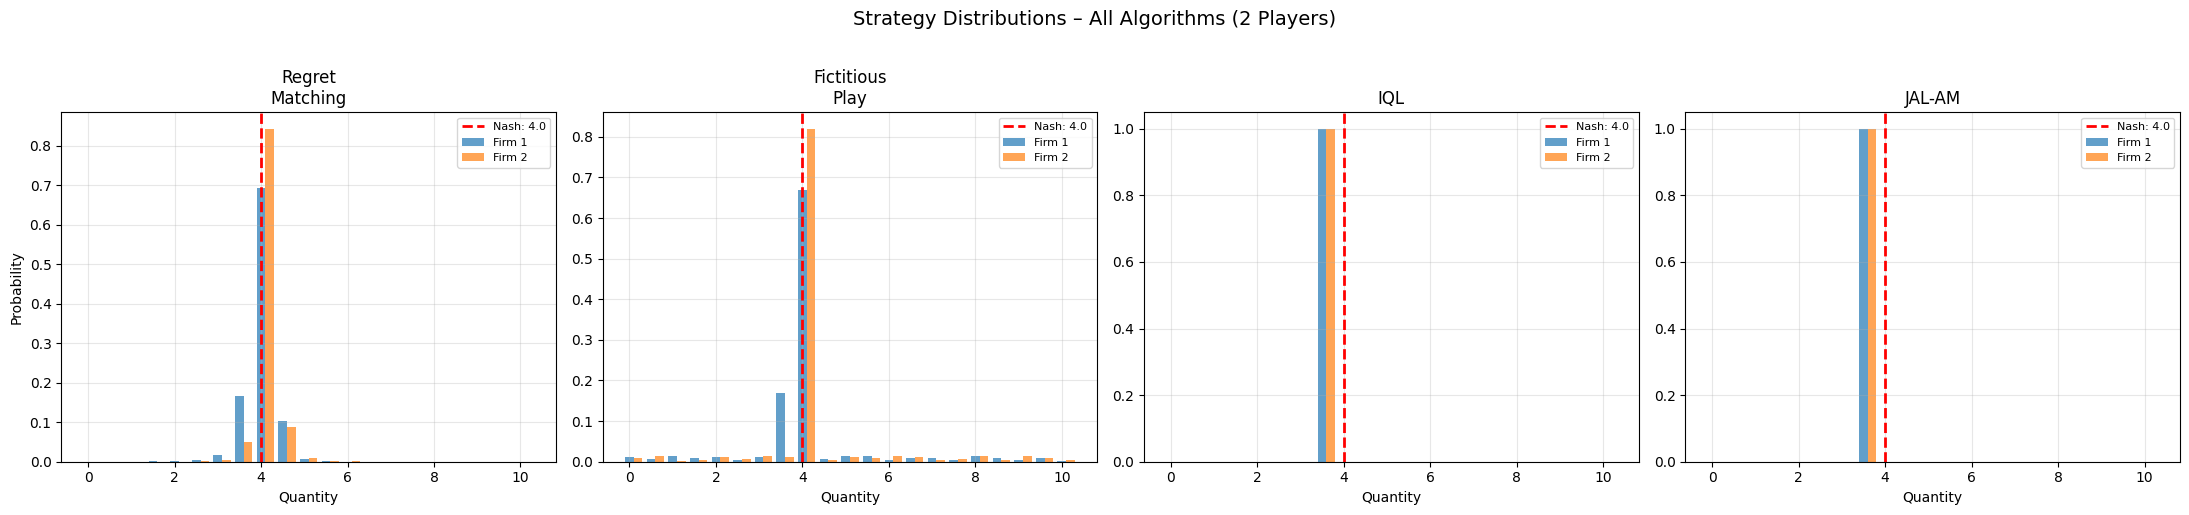

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
algo_info = [
    ('Regret\nMatching', rm),
    ('Fictitious\nPlay', fp),
    ('IQL', iql),
    ('JAL-AM', jalam),
]

for ax, (name, agents_dict) in zip(axes, algo_info):
    for j, agent in enumerate(g.agents):
        policy = agents_dict[agent].policy()
        ax.bar(g._quantities + j * 0.2, policy, alpha=0.7, label=f'Firm {j+1}', width=0.2)
    ax.axvline(x=q_star, color='red', linestyle='--', linewidth=2, label=f'Nash: {q_star:.1f}')
    ax.set_xlabel('Quantity', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Probability', fontsize=10)
plt.suptitle('Strategy Distributions – All Algorithms (2 Players)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Experimento Mixto: RM vs FP – ¿Quién llega primero al Equilibrio?

En este experimento las dos firmas usan algoritmos distintos:
- **Firma 0 (azul)**: Regret Matching
- **Firma 1 (naranja)**: Fictitious Play

Se registra en cada iteración la cantidad más probable según la política aprendida (`argmax` de la distribución) y se detecta automáticamente cuál agente alcanza primero la cantidad de Nash (dentro de la resolución de la grilla discreta).

In [19]:
g.reset()
rm_mix = RegretMatching(game=g, agent=g.agents[0], seed=42)
fp_mix = FictitiousPlay(game=g,  agent=g.agents[1], seed=42)
mixed_agents = {g.agents[0]: rm_mix, g.agents[1]: fp_mix}

iterations_mix = 500
history_mix = {'q_rm': [], 'q_fp': [], 'policy_q_rm': [], 'policy_q_fp': []}

for i in range(iterations_mix):
    actions = {agent: mixed_agents[agent].action() for agent in g.agents}
    obs, rewards, terms, truncs, infos = g.step(actions)

    history_mix['q_rm'].append(g._quantities[actions[g.agents[0]]])
    history_mix['q_fp'].append(g._quantities[actions[g.agents[1]]])
    history_mix['policy_q_rm'].append(g._quantities[np.argmax(rm_mix.policy())])
    history_mix['policy_q_fp'].append(g._quantities[np.argmax(fp_mix.policy())])

# Tolerancia = un paso de acción (resolución de la grilla discreta)
tol = g._quantities[1] - g._quantities[0]
conv_rm = next((i for i, q in enumerate(history_mix['policy_q_rm']) if abs(q - q_star) <= tol), None)
conv_fp = next((i for i, q in enumerate(history_mix['policy_q_fp']) if abs(q - q_star) <= tol), None)

print(f"Experimento mixto: firma 0 = RM, firma 1 = FP  (tolerancia ±{tol:.2f})")
print(f"  RM alcanza el Nash en iteración: {conv_rm}")
print(f"  FP alcanza el Nash en iteración: {conv_fp}")
if conv_rm is not None and conv_fp is not None:
    winner = 'RM' if conv_rm < conv_fp else 'FP'
    print(f"  → {winner} llega primero al equilibrio")
elif conv_rm is not None:
    print("  → RM llega al equilibrio; FP no converge en las iteraciones dadas")
elif conv_fp is not None:
    print("  → FP llega al equilibrio; RM no converge en las iteraciones dadas")

Experimento mixto: firma 0 = RM, firma 1 = FP  (tolerancia ±0.50)
  RM alcanza el Nash en iteración: 1
  FP alcanza el Nash en iteración: 7
  → RM llega primero al equilibrio


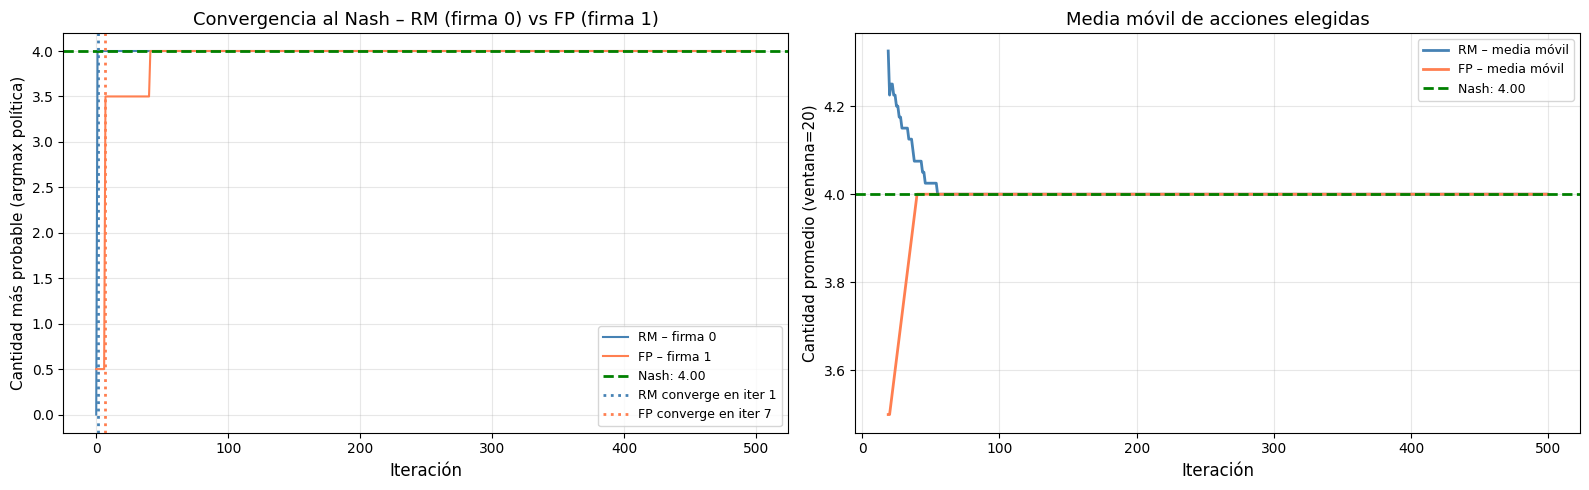

In [20]:
window = 20

q_rm_arr = np.array(history_mix['q_rm'])
q_fp_arr = np.array(history_mix['q_fp'])
roll_rm = np.convolve(q_rm_arr, np.ones(window) / window, mode='valid')
roll_fp = np.convolve(q_fp_arr, np.ones(window) / window, mode='valid')
roll_x = np.arange(window - 1, iterations_mix)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Política aprendida (argmax) en cada iteración
ax1.plot(history_mix['policy_q_rm'], color='steelblue', linewidth=1.5, label='RM – firma 0')
ax1.plot(history_mix['policy_q_fp'], color='coral',     linewidth=1.5, label='FP – firma 1')
ax1.axhline(y=q_star, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star:.2f}')
if conv_rm is not None:
    ax1.axvline(x=conv_rm, color='steelblue', linestyle=':', linewidth=2,
                label=f'RM converge en iter {conv_rm}')
if conv_fp is not None:
    ax1.axvline(x=conv_fp, color='coral', linestyle=':', linewidth=2,
                label=f'FP converge en iter {conv_fp}')
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Cantidad más probable (argmax política)', fontsize=11)
ax1.set_title('Convergencia al Nash – RM (firma 0) vs FP (firma 1)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Media móvil de las acciones elegidas
ax2.plot(roll_x, roll_rm, color='steelblue', linewidth=2, label='RM – media móvil')
ax2.plot(roll_x, roll_fp, color='coral',     linewidth=2, label='FP – media móvil')
ax2.axhline(y=q_star, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star:.2f}')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel(f'Cantidad promedio (ventana={window})', fontsize=11)
ax2.set_title('Media móvil de acciones elegidas', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Three-Player Cournot Competition

Now let's test the game with 3 firms to see how competition affects equilibrium outcomes.

## Nash Equilibrium for n Players

For n firms, the Nash equilibrium is:
- Equilibrium quantity per firm: $q^* = \frac{a - c}{(n+1)b}$
- Total market quantity: $Q^* = n \cdot q^*$
- Equilibrium price: $P^* = a - b \cdot Q^*$

In [21]:
# Create 3-player game with same parameters
g3 = Cournot(a=25.0, b=2.0, c=1.0, n_players=3, max_quantity=10, num_actions=21)
g3.reset()

print(f"Number of players: {g3.n_players}")
print(f"Agents: {g3.agents}")

Number of players: 3
Agents: ['agent_0', 'agent_1', 'agent_2']


## Nash Equilibrium (3 Players)

In [22]:
q_star_3, P_star_3, profit_star_3 = g3.get_nash_equilibrium()
print(f"Nash Equilibrium (3 players):")
print(f"  Quantity per firm: {q_star_3:.4f}")
print(f"  Total quantity: {3*q_star_3:.4f}")
print(f"  Price: {P_star_3:.4f}")
print(f"  Profit per firm: {profit_star_3:.4f}")
print(f"\nComparison with 2 players:")
print(f"  2 players: q*={q_star:.4f}, P*={P_star:.4f}, π*={profit_star:.4f}")
print(f"  3 players: q*={q_star_3:.4f}, P*={P_star_3:.4f}, π*={profit_star_3:.4f}")

Nash Equilibrium (3 players):
  Quantity per firm: 3.0000
  Total quantity: 9.0000
  Price: 7.0000
  Profit per firm: 18.0000

Comparison with 2 players:
  2 players: q*=4.0000, P*=9.0000, π*=32.0000
  3 players: q*=3.0000, P*=7.0000, π*=18.0000


## Test Nash Equilibrium Actions

In [23]:
# Test with Nash equilibrium quantities
g3.reset()
nash_action_3 = np.argmin(np.abs(g3._quantities - q_star_3))
actions_3 = {agent: nash_action_3 for agent in g3.agents}
obs, rewards, terms, truncs, infos = g3.step(actions_3)
g3.render()
print(f"\nExpected Nash profit: {profit_star_3:.4f}")

agent_0: quantity=3.00, profit=18.00
agent_1: quantity=3.00, profit=18.00
agent_2: quantity=3.00, profit=18.00

Expected Nash profit: 18.0000


## Learning with Regret Matching (3 Players)

In [24]:
g3.reset()
rm3 = dict(map(lambda agent: (agent, RegretMatching(game=g3, agent=agent, seed=42)), g3.agents))

In [25]:
history_3 = run_experiment_n(g3, rm3, iterations=1000)
print_strategy(g3, rm3, 'Regret Matching - 3 players', q_star_3)

Learned strategies (Regret Matching - 3 players):
  agent_0: Most probable quantity = 3.0000 (Nash: 3.0000)
  agent_1: Most probable quantity = 3.0000 (Nash: 3.0000)
  agent_2: Most probable quantity = 3.0000 (Nash: 3.0000)


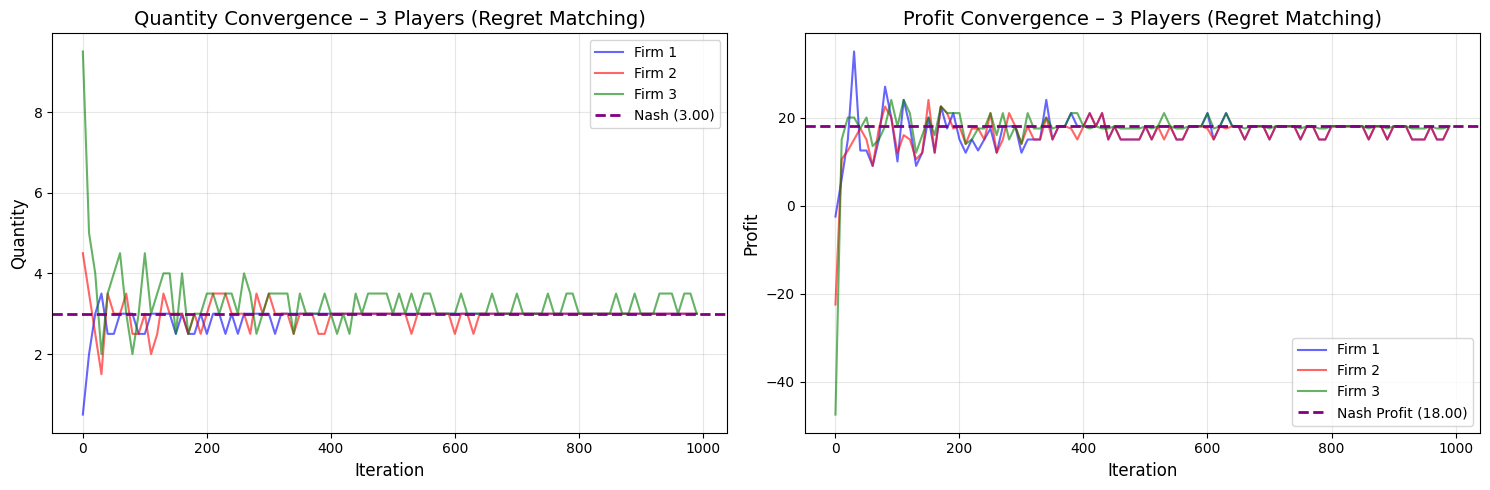

In [26]:
plot_convergence_n(g3, history_3, 1000, 10, q_star_3, profit_star_3, '3 Players (Regret Matching)')

## Learning with Fictitious Play (3 Players)

In [27]:
g3.reset()
fp3 = dict(map(lambda agent: (agent, FictitiousPlay(game=g3, agent=agent, seed=42)), g3.agents))

In [28]:
history_fp3 = run_experiment_n(g3, fp3, iterations=1000)
print_strategy(g3, fp3, 'Fictitious Play - 3 players', q_star_3)

Learned strategies (Fictitious Play - 3 players):
  agent_0: Most probable quantity = 3.0000 (Nash: 3.0000)
  agent_1: Most probable quantity = 3.0000 (Nash: 3.0000)
  agent_2: Most probable quantity = 3.0000 (Nash: 3.0000)


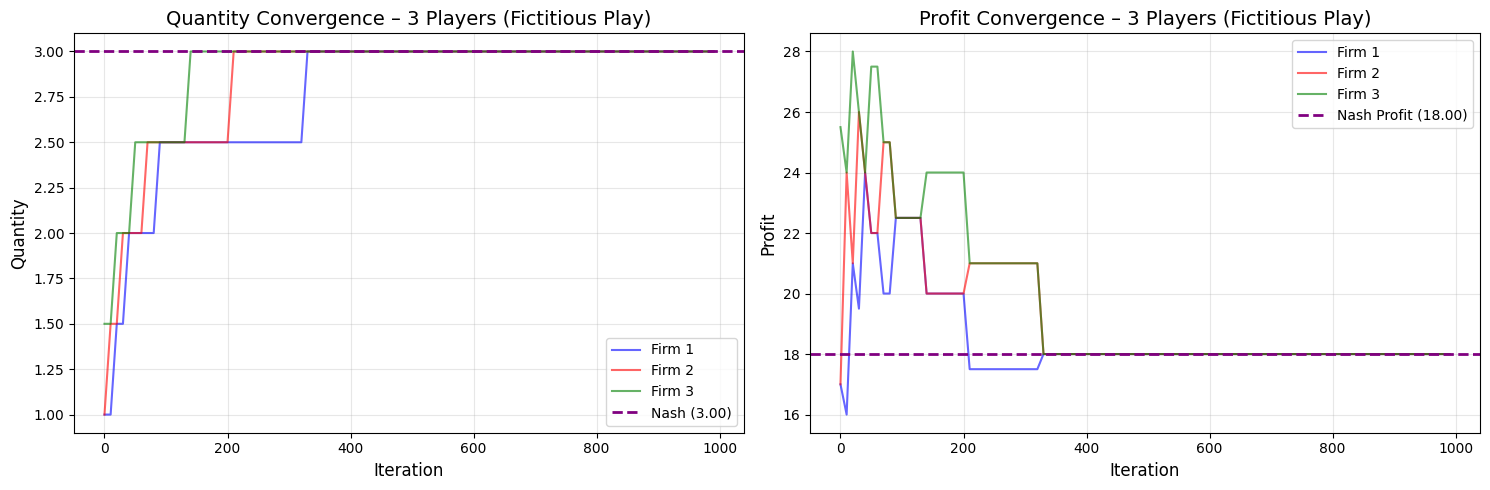

In [29]:
plot_convergence_n(g3, history_fp3, 1000, 10, q_star_3, profit_star_3, '3 Players (Fictitious Play)')

## Strategy Distribution – RM y FP (3 Players)

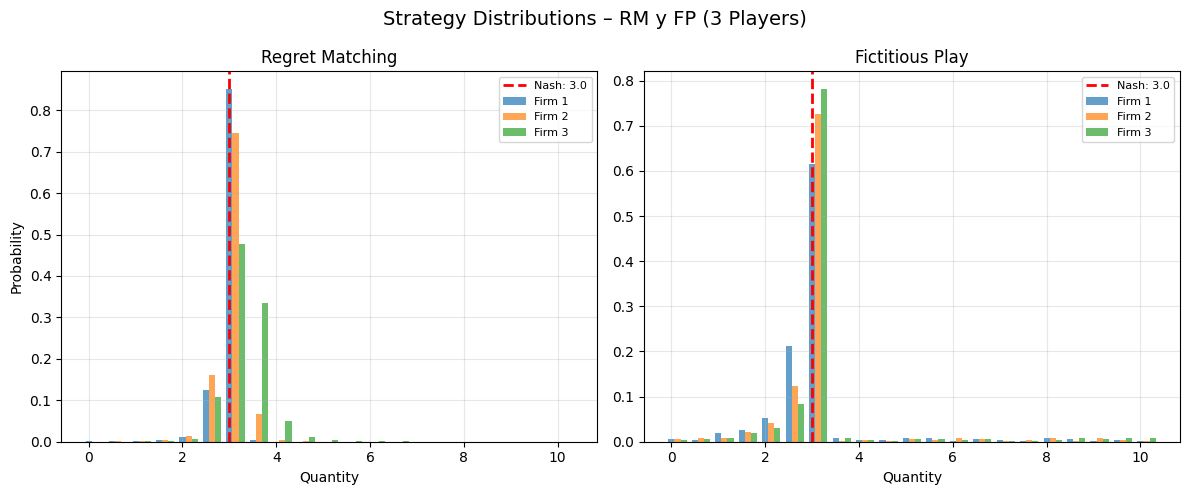

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
algo_info_3 = [('Regret Matching', rm3), ('Fictitious Play', fp3)]

for ax, (name, agents_dict) in zip(axes, algo_info_3):
    for j, agent in enumerate(g3.agents):
        policy = agents_dict[agent].policy()
        ax.bar(g3._quantities + j * 0.13, policy, alpha=0.7, label=f'Firm {j+1}', width=0.13)
    ax.axvline(x=q_star_3, color='red', linestyle='--', linewidth=2, label=f'Nash: {q_star_3:.1f}')
    ax.set_xlabel('Quantity', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Probability', fontsize=10)
plt.suptitle('Strategy Distributions – RM y FP (3 Players)', fontsize=14)
plt.tight_layout()
plt.show()

## Comparison: 2 Players vs 3 Players

Compare market outcomes with different numbers of firms:

In [31]:
# Create comparison table
comparison_data = {
    'Number of Firms': [2, 3],
    'q* (per firm)': [q_star, q_star_3],
    'Q* (total)': [2*q_star, 3*q_star_3],
    'P* (price)': [P_star, P_star_3],
    'π* (per firm)': [profit_star, profit_star_3],
    'Total Industry Profit': [2*profit_star, 3*profit_star_3]
}

print("Impact of Number of Firms on Market Outcomes:")
print("="*80)
print(f"{'Firms':<10} {'q* (each)':<12} {'Q* (total)':<12} {'P*':<10} {'π* (each)':<12} {'Total π*':<12}")
print("="*80)
for i in range(len(comparison_data['Number of Firms'])):
    n = comparison_data['Number of Firms'][i]
    q = comparison_data['q* (per firm)'][i]
    Q = comparison_data['Q* (total)'][i]
    P = comparison_data['P* (price)'][i]
    pi = comparison_data['π* (per firm)'][i]
    total_pi = comparison_data['Total Industry Profit'][i]
    print(f"{n:<10} {q:<12.4f} {Q:<12.4f} {P:<10.4f} {pi:<12.4f} {total_pi:<12.4f}")
print("="*80)
print("\nObservations:")
print("  • As the number of firms increases:")
print("    - Each firm produces less (q* decreases)")
print("    - Total market quantity increases (Q* increases)")
print("    - Price decreases (P* decreases)")
print("    - Profit per firm decreases (π* decreases)")
print("    - Total industry profit decreases")
print("  • Market becomes more competitive, approaching perfect competition")

Impact of Number of Firms on Market Outcomes:
Firms      q* (each)    Q* (total)   P*         π* (each)    Total π*    
2          4.0000       8.0000       9.0000     32.0000      64.0000     
3          3.0000       9.0000       7.0000     18.0000      54.0000     

Observations:
  • As the number of firms increases:
    - Each firm produces less (q* decreases)
    - Total market quantity increases (Q* increases)
    - Price decreases (P* decreases)
    - Profit per firm decreases (π* decreases)
    - Total industry profit decreases
  • Market becomes more competitive, approaching perfect competition


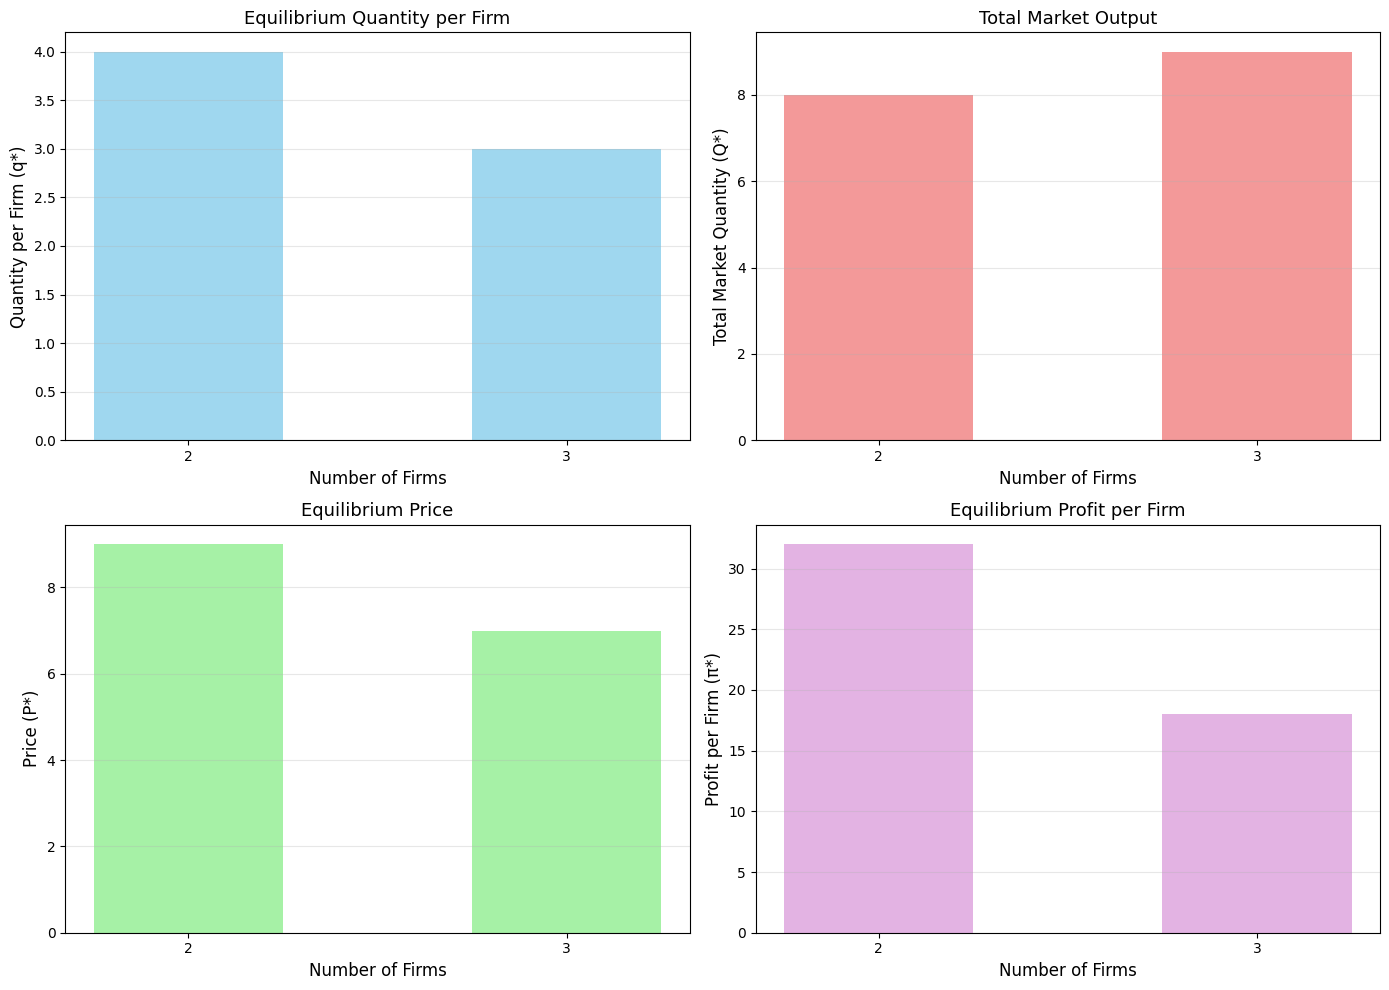

In [32]:
# Visualize the comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

n_firms = [2, 3]
q_per_firm = [q_star, q_star_3]
Q_total = [2*q_star, 3*q_star_3]
prices = [P_star, P_star_3]
profit_per_firm = [profit_star, profit_star_3]

# Quantity per firm
ax1.bar(n_firms, q_per_firm, color='skyblue', alpha=0.8, width=0.5)
ax1.set_xlabel('Number of Firms', fontsize=12)
ax1.set_ylabel('Quantity per Firm (q*)', fontsize=12)
ax1.set_title('Equilibrium Quantity per Firm', fontsize=13)
ax1.set_xticks(n_firms)
ax1.grid(True, alpha=0.3, axis='y')

# Total market quantity
ax2.bar(n_firms, Q_total, color='lightcoral', alpha=0.8, width=0.5)
ax2.set_xlabel('Number of Firms', fontsize=12)
ax2.set_ylabel('Total Market Quantity (Q*)', fontsize=12)
ax2.set_title('Total Market Output', fontsize=13)
ax2.set_xticks(n_firms)
ax2.grid(True, alpha=0.3, axis='y')

# Price
ax3.bar(n_firms, prices, color='lightgreen', alpha=0.8, width=0.5)
ax3.set_xlabel('Number of Firms', fontsize=12)
ax3.set_ylabel('Price (P*)', fontsize=12)
ax3.set_title('Equilibrium Price', fontsize=13)
ax3.set_xticks(n_firms)
ax3.grid(True, alpha=0.3, axis='y')

# Profit per firm
ax4.bar(n_firms, profit_per_firm, color='plum', alpha=0.8, width=0.5)
ax4.set_xlabel('Number of Firms', fontsize=12)
ax4.set_ylabel('Profit per Firm (π*)', fontsize=12)
ax4.set_title('Equilibrium Profit per Firm', fontsize=13)
ax4.set_xticks(n_firms)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Comparación Final de Algoritmos

RM y FP se evalúan en 2 y 3 jugadores. IQL y JAL-AM solo se evalúan en 2 jugadores: dado que no convergen al Nash en ese escenario más simple, no tiene sentido extender el experimento a 3 jugadores.

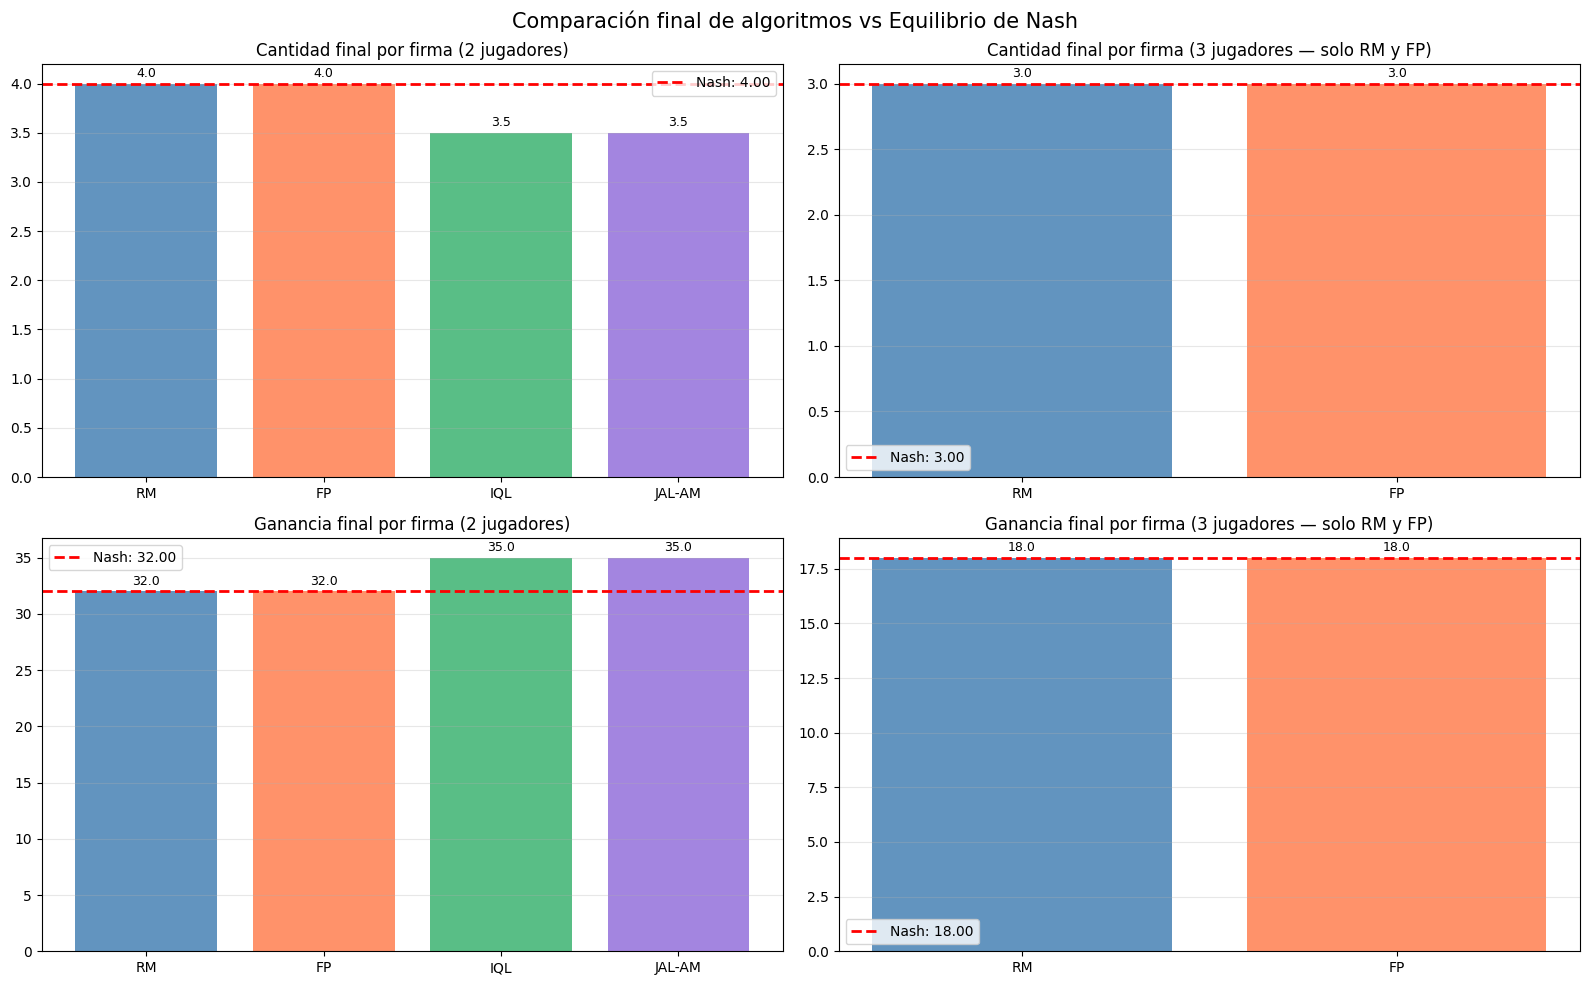

In [33]:
algo_names_2p = ['RM', 'FP', 'IQL', 'JAL-AM']
algo_names_3p = ['RM', 'FP']
colors_2p     = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
colors_3p     = ['steelblue', 'coral']
agents_2p     = [rm, fp, iql, jalam]
agents_3p     = [rm3, fp3]

final_q_2p      = [get_final_q(g,   a) for a in agents_2p]
final_q_3p      = [get_final_q(g3,  a) for a in agents_3p]
final_profit_2p = [get_avg_profit(g,  a) for a in agents_2p]
final_profit_3p = [get_avg_profit(g3, a) for a in agents_3p]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, vals, names, colors, nash, title in [
    (axes[0, 0], final_q_2p,      algo_names_2p, colors_2p, q_star,        'Cantidad final por firma (2 jugadores)'),
    (axes[0, 1], final_q_3p,      algo_names_3p, colors_3p, q_star_3,      'Cantidad final por firma (3 jugadores — solo RM y FP)'),
    (axes[1, 0], final_profit_2p, algo_names_2p, colors_2p, profit_star,   'Ganancia final por firma (2 jugadores)'),
    (axes[1, 1], final_profit_3p, algo_names_3p, colors_3p, profit_star_3, 'Ganancia final por firma (3 jugadores — solo RM y FP)'),
]:
    bars = ax.bar(names, vals, color=colors, alpha=0.85)
    ax.axhline(y=nash, color='red', linestyle='--', linewidth=2, label=f'Nash: {nash:.2f}')
    ax.legend()
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, max(bar.get_height(), 0) + abs(nash) * 0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación final de algoritmos vs Equilibrio de Nash', fontsize=15)
plt.tight_layout()
plt.show()

## Conclusiones

- En el juego de Cournot, el equilibrio de Nash ocurre cuando ninguna firma tiene incentivos a cambiar unilateralmente su cantidad producida. En nuestros experimentos, esto ocurre en $q^* = 4$ para 2 jugadores y en $q^* = 3$ para 3 jugadores.

- De acuerdo con la performance observada para cada agente, podemos concluir:

    - **Random Agent**: funciona como baseline y confirma que, sin aprendizaje, no aparece ningún tipo de coordinación ni convergencia estable.

    - **Independent Q-Learning (IQL)**: fue uno de los agentes más inestables. Debido a la no-estacionariedad del entorno multiagente, el algoritmo no logra converger correctamente y suele estabilizarse en cantidades cercanas a $q \approx 3.5$, que no corresponden al equilibrio de Nash.

     - **JAL-AM**: performó mejor que IQL porque modela explícitamente las acciones del oponente, pero igualmente presentó oscilaciones y no logró converger al equilibrio de Nash de forma consistente.

    - **Fictitious Play (FP)**: aproximó correctamente el equilibrio de Nash tanto en 2 como en 3 jugadores. Fue uno de los algoritmos más estables, aunque necesitó más iteraciones para converger porque depende de estimar la estrategia histórica del oponente.

    - **Regret Matching (RM)**: performó de manera muy similar a FP y fue uno de los agentes que mejor capturó el comportamiento esperado teóricamente para Cournot.
    
    - (**RM vs FP**), RM converge más rápido que FP. Esto tiene sentido porque RM empieza a ajustar su estrategia usando regrets acumulados desde el inicio, mientras que FP necesita observar suficientes jugadas del oponente para construir una buena estimación de su política.

- Algo interesante observado en IQL y JAL-AM es que, aunque a veces alcanzan recompensas mayores que las del equilibrio de Nash, eso no implica que hayan encontrado una solución estable. Los agentes pueden quedar temporalmente en regiones que parecen buenas, pero donde cualquier pequeño cambio en la estrategia de uno de los jugadores hace que el otro tenga incentivos a desviarse.

- En general, RM y FP fueron los algoritmos que mejor capturaron el comportamiento esperado teóricamente para Cournot, mientras que IQL y JAL-AM reflejaron las dificultades clásicas de aprendizaje por refuerzo en entornos multiagente no estacionarios.